<div style="box-sizing:border-box;max-width:100%;margin:0 0 8px;padding:4px 0;color:inherit;line-height:1.35;"><img src="https://thetahat.ru/images/logo_thetahat.png" alt="ThetaHat" style="display:block!important;width:52px!important;max-width:52px!important;height:auto!important;margin:0 0 9px 0!important;padding:0!important;"><div style="display:flex;align-items:center;justify-content:space-between;flex-wrap:wrap;gap:8px 12px;"><span style="min-width:0;color:inherit;font-size:12px;font-weight:700;letter-spacing:0.055em;text-transform:uppercase;"><a href="https://thetahat.ru/courses/ysda-group" style="color:inherit;text-decoration:none;">Школа анализа данных</a>&nbsp;·&nbsp;Машинное обучение</span></div></div>

<h2><span style="display:block;box-sizing:border-box;max-width:100%;padding:16px 22px 17px;border-radius:14px;background:linear-gradient(135deg,#D4470E 0%,#C7324E 50%,#B316B8 100%);color:#FFFFFF;line-height:1.15;font-weight:500;">Занятие 1. Модели и их обучение на примере распознавания рукописных цифр. </span></h2>

Scikit-learn (или sklearn) — это одна из наиболее популярных библиотек для машинного обучения на языке Python. Она предоставляет множество инструментов для анализа данных и построения моделей, что делает её идеальным выбором как для начинающих, так и для опытных специалистов в области анализа данных и машинного обучения.

Давайте погрузимся в возможности данной библиотеки.


In [1]:
# Установите библиотеку, если у вас ее нет
# !pip install scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from typing import Tuple, List
from pandas import Series
from typing import List, Any, Tuple, Dict, Optional, Union
from pandas import DataFrame
from pandas.io.formats.style import Styler

# обратите внимание, что Scikit-Learn импортируется как sklearn
from sklearn import datasets
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_regression

# фиксируем seed для воспроизводимости результатов
RANDOM_STATE = 42
rng = np.random.RandomState(RANDOM_STATE)


## <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">1</span> <span style="color:inherit;">Датасет MNIST</span>

Пакет `sklearn.datasets` позволяет загружать наборы данных из репозитория. Загрузим датасет **MNIST**.

Датасет **MNIST** (Modified National Institute of Standards and Technology) — это один из самых известных и широко используемых наборов данных для обучения и тестирования методов машинного обучения, особенно в области распознавания изображений. Он состоит из рукописных цифр и часто используется для задач классификации.



In [3]:
mnist = fetch_openml("mnist_784")

**Изображения**

Данные изображений хранятся в переменной `data`. Каждый объект в наборе данных представлен в виде **черно-белого** (в градациях серого) изображения размером **28x28 пикселей**.

Каждый пиксель имеет значение в диапазоне от **0 до 255**, где:

- **0** соответствует полностью черному цвету (это фон),
- **255** — полностью белому (это сама цифра).

Таким образом, чем выше значение пикселя, тем светлее он выглядит, приближаясь к белому цвету.

**Метки**

Каждое изображение связано с **меткой класса**, представляющей собой одну из цифр от **0 до 9**. Эта метка указывает, какую именно цифру содержит данное изображение. Метки классов, соответствующие изображениям, хранятся в переменной `target`.

---

Визуализируем данные:

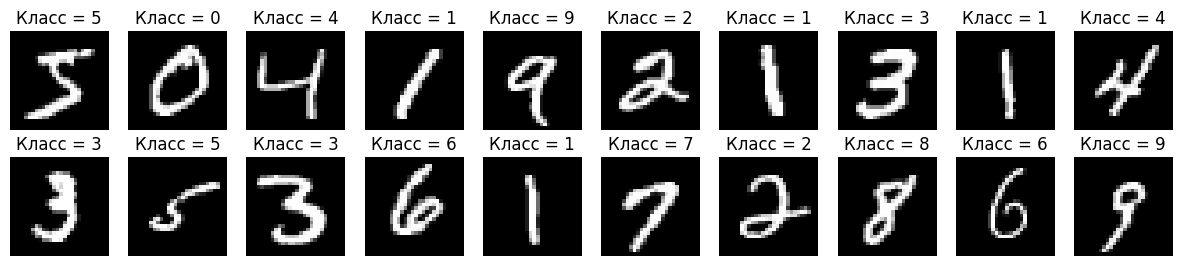

In [4]:
plt.figure(figsize=(15, 3))
num_figures = 20

for i in range(num_figures):
    plt.subplot(2, 10, i + 1)
    # выводим само изображение
    plt.imshow(np.array(mnist["data"])[i].reshape(28, 28), cmap="gray")
    # выводим истинные и предсказанные метки
    plt.title(f"Класс = {mnist['target'][i]}")
    plt.axis("off")
plt.show()

Наши данные представлены в виде матриц, а многие модели машинного обучения работают с векторами. Следовательно нам придется преобразовать все матрицы в вектора, т.е. просто растянуть их.

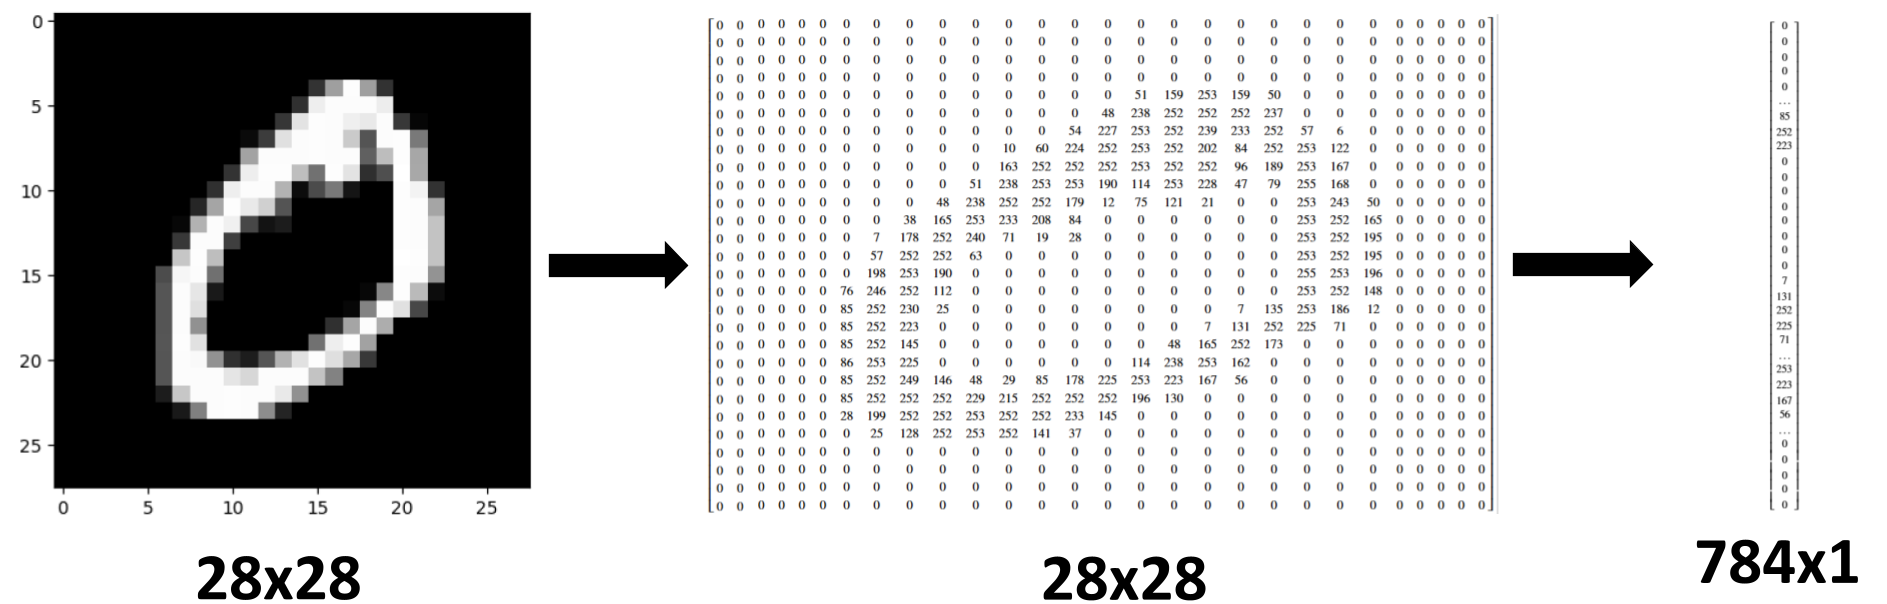

Разделим данные и переведем их в вектор.

In [5]:
n_samples = len(mnist["data"])
X, y = mnist["data"].to_numpy().reshape(n_samples, -1), mnist["target"].to_numpy()

X.shape, y.shape

((70000, 784), (70000,))

Как мы видим, каждая строка имеет 784 признака, что соответствует общему числу пикселей на картинке 28x28, т.е. матрица изображения растянулась в вектор.

## <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">2</span> <span style="color:inherit;">Теория о данных ⚙️</span>

**Объекты**

Набор элементов $X_1, ..., X_n$ называется **выборкой**. В классической постановке задачи мы предполагаем, что каждый объект $X_i$ описывается вектором из $d$ действительных чисел: $X_i \in \mathbb{R}^d$. Компоненты этого вектора называются **признаками** (features), а размерность пространства $d$ — количеством признаков.

Если мы рассмотрим набор чисел $X_{1j}, \ldots, X_{nj}$, то получим все значения конкретного $j$-го признака по всей выборке.

> **Пример:**
> Предположим, что мы решаем задачу оценки стоимости недвижимости.
> *   *Объект $X_i$:* Конкретная квартира.
> *   *Признаки:*
>     1.  Общая площадь: $x_{i1} = 45.5\ м^2$.
>     2.  Расстояние до метро: $x_{i2} = 1.2$ км.
>     3.  Этаж: $x_{i3} = 5$.
> *   *Выборка:* База данных из $n=1000$ проданных квартир.

**Матричное представление объектов**

В случае $X_i = (x_{i1}, \ldots, x_{id})^T \in \mathbb{R}^d$ набор данных удобно представлять в виде матрицы «объект–признак»:

$$X = \begin{pmatrix} x_{11} & \ldots & x_{1d} \\ \vdots & \ddots & \vdots \\ x_{n1} & \ldots & x_{nd}\end{pmatrix}$$

По строкам этой матрицы располагаются объекты, по столбцам — признаки.

**Таргеты**

Набору $X_1, ..., X_n$ соответствует набор таргетных меток $Y_1, ..., Y_n$.

> **Примеры.**
> * Для тех же квартир таргетом может быть цена: $Y_i$ — стоимость $i$-й квартиры в рублях.
> * Для пациентов клиники — наличие или отсутствие заболевания: $Y_i \in \{0, 1\}$.
> * Для фотографий рукописных цифр — сама цифра: $Y_i \in \{0, 1, \ldots, 9\}$.



**Цель**

Построить функцию $y: \mathbb{R}^d \to \mathscr{Y}$, где $\mathscr{Y}$ — множество значений таргета, которая *как можно лучше* приближает зависимость $Y_i$ от $X_i$. Такая функция называется **моделью**. Понятие «*как можно лучше*» определяется отдельно для каждой конкретной задачи.

Часто выделяют два основных случая:
* Если $\mathscr{Y} = \mathbb{R}$ (или какой-либо интервал в $\mathbb{R}$), задачу приближения зависимости называют **задачей регрессии**.
* Если $\mathscr{Y}$ дискретно и содержит "разумное" количество значений, задачу приближения зависимости называют **задачей классификации**.

Такое деление условно и служит скорее для удобства. Например, если мы предсказываем количество проданных упаковок шоколада, значения $Y$ будут дискретными и целочисленными. Более того, поскольку объём шоколада физически ограничен, множество возможных значений $Y$ конечно. Тем не менее с практической точки зрения рассматривать эту задачу как классификацию не имеет смысла.


**Случайная природа данных**

Обычно предполагается, что таргеты — случайные объекты, представимые в виде
$$Y_i = y_{*}(x_i, \varepsilon_i),$$
где $\varepsilon_1, ..., \varepsilon_n$ — неизвестный случайный шум, представимый в виде независимых случайных величин, а $y_{*}$ — неизвестная функция.

Такое представление справедливо как для задачи регрессии, так и для задачи классификации.

> **Примеры природы шума:**
> * **Бросок монеты.** Существуют законы физики, которые позволяют точно рассчитать, как упадет монета (сила броска, сопротивление воздуха, угол). Но на практике мы не можем измерить эти параметры идеально точно. Эти неизмеренные микро-факторы и образуют «шум» $\varepsilon$, делая исход для нас случайным.
> * **Покупка в магазине.** Решение клиента купить товар зависит от множества факторов. Часть из них мы знаем: история покупок, цена, скидки ($X_i$). Но есть скрытые факторы: плохое настроение, «встал не с той ноги», суеверия (черная кошка перебежала дорогу). Поскольку мы не можем оцифровать эти скрытые факторы, в модели они превращаются в случайный шум.


Исходный датасет необходимо разделить на две непересекающиеся части:
1.  **Тренировочная** ($X_{train}, Y_{train}$) — используется непосредственно для обучения модели.
2.  **Тестовая** ($X_{test}, Y_{test}$) — используется только для финальной оценки качества. В процессе обучения модель эти данные не видит.

Это необходимо для проверки **обобщающей способности** — умения модели работать с новыми объектами. Оценивать качество на тех же данных, на которых модель училась, некорректно: она могла просто «запомнить» примеры, не выявив закономерности.

> **Аналогия:**
> Студент готовится по задачам из учебника (**train**), но его знания проверяются на экзамене с новыми задачами (**test**). Если задачи совпадут, студент может сдать экзамен, просто вызубрив ответы, но не поняв предмета. То же самое относится и к критериям проверки домашних заданий 😊

Для этого есть готовая функция [train_test_split](https://scikit-learn.org/dev/modules/generated/sklearn.model_selection.train_test_split.html) из модуля `sklearn.model_selection`.

`train_test_split(arrays, test_size=None, train_size=None, random_state=None)`
- `arrays`: массивы данных для разделения (например, признаки $X$ и таргет $y$).
- `test_size`: размер тестовой выборки. Может быть числом (количество образцов) или долей от общего числа образцов.
- `train_size`: размер обучающей выборки. Может быть числом (количество образцов) или долей от общего числа образцов.
- `random_state`: устанавливает начальное значение для генератора случайных чисел (повторяемость разделения данных).

*Примечание:*  Если параметры в `test_size`, `train_size` передать `None`, то размер тестовой выборки составит 25%.

> &#x2757; **Важно:** При обучении модель ничего не должна знать о тестовой выборке.

Разделим данные на тренировочную выборку и тестовую.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=RANDOM_STATE
)

Теперь мы готовы с обучению и сравнению различных моделей машинного обучения.

## <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">3</span> <span style="color:inherit;">Обучение и применение моделей ⚙️</span>

Пусть $\mathcal{M} = \{y: \mathbb{R}^d \to \mathscr{Y}\}$ — это **семейство моделей**, представляющее набор всех функций-кандидатов, среди которых мы будем искать решение.

**Обучение (оценка, вывод)** — выбор конкретной модели $\widehat{y} \in \mathcal{M}$ на основе обучающей выборки. Иными словами, из всех возможных функций мы выбираем ту, которая лучше всего описывает наши данные.

> *Пример* 
> 
> Вы просите голосовой ассистент распознать вашу речь. «Под капотом» работает модель, которую кто-то когда-то выбрал и настроил по тысячам записей человеческой речи — это и было обучение.

**Метод обучения** — конкретный способ выбора $\widehat{y} \in \mathcal{M}$.

Частая ситуация: задаётся некоторый **функционал ошибки** $L(y, z)$ — «штраф» за предсказание $z \in \mathscr{Y}$ вместо правильного ответа $y \in \mathscr{Y}$. Тогда метод обучения сводится к задаче оптимизации:

$$\sum_{i=1}^n L(Y_i, y(X_i)) \to \min_{y \in \mathcal{M}}$$

То есть мы ищем модель, которая суммарно ошибается как можно меньше на обучающей выборке.

> *Пример* 
> 
> Представьте, что вы предсказываете цену квартиры. Если настоящая цена — 10 млн, а модель сказала 12 млн, штраф может быть равен $(10 - 12)^2 = 4$. Мы хотим, чтобы сумма таких штрафов по всем квартирам была минимальной.



### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">3.1</span> <span style="color:inherit;">Виды методов обучения</span>

**1. Параметрический подход**

Множество моделей задаётся через параметры:

$$\mathcal{M} = \{y_\theta\colon \mathbb{R}^d \to \mathscr{Y}\ |\ \theta \in \Theta\},$$

где $\Theta$ — множество параметров. Тогда обучение сводится к выбору $\theta \in \Theta$.

> *Пример*
> 
> Простейшая параметрическая модель — уравнение прямой $y = a  x + b$.
> Здесь структура жесткая (линия), а параметры $\theta = (a, b)$. Обучение — это подбор чисел $a$ и $b$ так, чтобы прямая прошла как можно ближе точкам данных.
>
> Нейросети (включая те, на которых работают ChatGPT или подобные) — это параметрические модели. Только параметров $\theta$ (весов) там не два, а сотни миллиардов. Обучение такой сети — это долгая математическая настройка этих миллиардов "рычажков".

**2. Непараметрический подход**

Параметр явно не задаётся — модель выбирается из $\mathcal{M}$ напрямую, без предположений о конкретной функциональной форме.

> *Пример* 
> 
> Чтобы предсказать цену квартиры, мы просто находим в обучающей выборке несколько наиболее похожих квартир и усредняем их цены. Никаких формул с параметрами — только данные и понятие «похожести».

## <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">4</span> <span style="color:inherit;">Бейзлайн-модели</span>

**Бейзлайн-модель** — это простая модель, с которой мы будем сравнивать все последующие, более сложные подходы. Она задаёт минимальный уровень качества, который наша «настоящая» модель обязана превосходить.

Например, если ваша сложная нейросеть, которая обучалась неделю, работает не лучше, чем простая формула или случайное угадывание, значит, в проекте что-то пошло не так.

**Что брать за бейзлайн?**
1.  **Тривиальные модели (Dummy models)** 

     Константные предсказания или генераторы случайных чисел (см. стратегии ниже). С них нужно начинать всегда, чтобы оценить минимально допустимый порог качества. </br></br>
     
     
2.  **Текущее решение («SOTA» вашего проекта)** 

    Если в компании уже работает какая-то система (например, менеджер вручную проставляет категории или работает простой набор правил `if-else`), то именно она становится бейзлайном. Наша задача — сделать модель, которая работает лучше *существующего* процесса.


Все основные бейзлайн-модели также реализованы в `sklearn` в классе `DummyClassifier`. Эти стратегии не используют признаки объектов ($X$), они смотрят только на распределение таргетов ($Y$) в обучающей выборке.

`DummyClassifier(strategy)`

- `strategy`: стратегия для классификации

Разберем несколько из ниx

### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">4.1</span> <span style="color:inherit;">Стратегия "самый частый класс"</span>

`DummyClassifier(strategy="most_frequent")`


Модель всегда предсказывает класс, который чаще всего встречался **в обучении**, игнорируя входные данные.

> **Пример:**
> Задача: поиск редкой болезни.
> *   Здоровых: 99%
> *   Больных: 1%
>
> Бейзлайн всегда будет говорить «Здоров». Его точность (Accuracy) составит 99%. Это **очень высокая планка**. Если ваша «умная» модель выдаст точность 95%, она бесполезна, так как проигрывает даже глупому бейзлайну.

In [7]:
dummy_clf = DummyClassifier(strategy="most_frequent")

Для обучения *любой* модели в sklearn-е используется метод класса  `fit(X_train, y_train)`.

- `X_train`: массив признаков обучающей выборки.
- `y_train`: массив меток классов обучающей выборки.

In [8]:
dummy_clf.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


<div style="box-sizing:border-box;max-width:100%;margin:14px 0 0;padding:0;border:1px solid rgba(199,50,78,0.20);border-bottom:0;border-radius:12px 12px 0 0;overflow:hidden;color:inherit;"><span style="display:inline-block;padding:4px 11px;border-radius:4px 12px 12px 4px;background:linear-gradient(135deg,#D4470E,#C7324E,#B316B8);color:white;font-size:10.5px;font-weight:800;letter-spacing:0.06em;text-transform:uppercase;white-space:nowrap;">Вопрос</span></div>

<div style="box-sizing:border-box;max-width:100%;padding:10px 14px 13px;border-left:1px solid rgba(199,50,78,0.20);border-right:1px solid rgba(199,50,78,0.20);border-bottom:1px solid rgba(199,50,78,0.20);border-radius:0 0 12px 12px;margin-bottom:8px;">

<div style="box-sizing:border-box;max-width:100%;padding:10px 14px 13px;border-left:1px solid rgba(199,50,78,0.20);border-right:1px solid rgba(199,50,78,0.20);border-bottom:1px solid rgba(199,50,78,0.20);border-radius:0 0 12px 12px;margin-bottom:8px;">

Что метод `fit` сделал в данном случае? Что есть обучение `DummyClassifier`?

</div>

</div>

<details style="box-sizing:border-box;max-width:100%;margin:0 0 18px;padding:8px 14px 10px;border:1px solid rgba(199,50,78,0.20);border-radius:10px;color:inherit;">

<summary style="cursor:pointer;color:inherit;font-size:13px;font-weight:750;text-decoration:underline;text-decoration-color:#C7324E;text-decoration-thickness:1.5px;text-underline-offset:3px;">Показать ответ</summary>

> 1. Вход `fit(X, y)`: Модель получает массив меток, например `y = [0, 1, 1, 1, 0, 8]`.
> 2. Процесс: Она считает частоту каждого класса.
>     * Метка 0: 2 шт.
>     * Метка 1: 3 шт. (Победитель!)
>     * Метка 8: 1 шт.
> 3. Результат ("Веса модели"): Она сохраняет в свою внутреннюю память одно число/переменную.
> Она запоминает, что класс 1 — самый популярный.

</details><br/>


Посмотрим на список классов и их частоты:

In [9]:
dummy_clf.class_prior_, dummy_clf.classes_

(array([0.09887755, 0.1125102 , 0.09912245, 0.10132653, 0.0997551 ,
        0.0897551 , 0.09771429, 0.10295918, 0.09863265, 0.09934694]),
 array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object))

Теперь когда мы обучили модель, мы можем использовать ее для получения предсказаний. Для этого аналогично обучению существует метод `model.predict(X_test) `

- `X_test`: массив признаков тестовой выборки.

In [10]:
y_pred = dummy_clf.predict(X_test)

> Что метод `predict` сделал в данном случае? Что есть предсказание kNN?

<details>
  <summary> Кликни для показа ответа </summary>
  
> Когда вы даете ей новую картинку, она даже не смотрит на неё. Она Смотрит в массив class_prior_.
Находит там максимальное число.
Берет соответствующий класс из classes_.
</details><br/>

### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">4.2</span> <span style="color:inherit;">Визуализация результатов</span>

Давайте посмотрим на то, как предсказанные значения согласуются с реальными.

In [11]:
def get_random_image(
    X: np.ndarray,
    predicted_labels: np.ndarray,
    real_labels: np.ndarray
) -> Tuple[np.ndarray, int, int]:
    """
    Выбирает случайный элемент из выборки и возвращает матрицу изображения,
    метки класса, предсказанные моделью, и реальные.

    Принимает:
    * X - Матрица изображений.
    * predicted_labels - Массив предсказанных меток классов.
    * real_labels -  Массив реальных меток классов.
    Возвращает:
    * random_digit_image - Случайное изображение, преобразованное в матрицу размером 8x8.
    * random_digit_label - Предсказанная метка класса для выбранного изображения.
    * real_label - Реальная метка класса для выбранного изображения.
    """

    # выбираем случайный индекс из тестовой выборки
    random_digit_number = np.random.randint(1, len(y_test))
    # преобразуем вектор признаков обратно в матрицу
    random_digit_image = X[random_digit_number].reshape(int(np.sqrt(X.shape[1])), int(np.sqrt(X.shape[1])))
    # предсказанная метка
    random_digit_label = predicted_labels[random_digit_number]
    # реальная метка
    real_label = real_labels[random_digit_number]

    return random_digit_image, random_digit_label, real_label

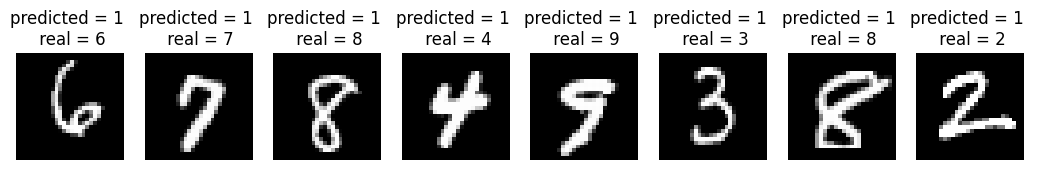

In [12]:
plt.figure(figsize=(13, 2))

for i in range(8):
    plt.subplot(1, 8, i + 1)
    image, predicted_label, real_label = get_random_image(X_test, y_pred, y_test)
    # выводим само изображение
    plt.imshow(image, cmap="gray")
    # выводим истинные и предсказанные метки
    plt.title(f"predicted = {predicted_label} \n real = {real_label}")
    plt.axis("off")
plt.show()

Как видим, все цифры классифицированы как единицы. Это не слишком информативно — нам хотелось бы иметь **числовую характеристику** качества предсказаний, чтобы можно было сравнивать разные модели между собой.

### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">4.3</span> <span style="color:inherit;">Метрика и качество модели</span>

Самая естественная идея — посчитать долю правильно угаданных объектов. Такой критерий качества называется **accuracy** (точность).

Пусть $Y_1, \ldots, Y_n$ — истинные значения, а $\widehat{Y}_1, \ldots, \widehat{Y}_n$ — предсказания модели. Тогда
$$\text{Accuracy} = \frac{1}{n} \sum_{i=1}^{n} I\{Y_i = \widehat{Y}_i\}$$

Как вы уже могли догадаться, в sklearn-е есть готовая [реализация](https://scikit-learn.org/1.5/modules/generated/sklearn.metrics.accuracy_score.html) этой метрики в модуле `sklearn.metrics` функция `accuracy_score`.

`accuracy_score(y_true, y_pred)`

- `y_true`: массив меток класса на тестовом наборе данных
- `y_pred`: массив меток класса предсказанный нашей моделью

Оценим качество нашей модели по метрике accuracy.

In [13]:
score = accuracy_score(y_test, y_pred)
print(f"метрика accuracy = {score*100:.2f}%")

метрика accuracy = 11.26%


Теперь мы можем утверждать, что предсказание самым частым классом обеспечивает качество accuracy 11%. Рассмотрим еще несколько бейзланй моделей.



### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">4.4</span> <span style="color:inherit;">Стратегия "полный рандом"</span>

`DummyClassifier(strategy="uniform")`

Каждый класс предсказывается с равной вероятностью $1/K$, где $K$ — количество классов. Используется реже, в основном как проверка на случайность.


In [14]:
dummy_clf = DummyClassifier(strategy="uniform")
dummy_clf.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'uniform'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


<div style="box-sizing:border-box;max-width:100%;margin:14px 0 0;padding:0;border:1px solid rgba(199,50,78,0.20);border-bottom:0;border-radius:12px 12px 0 0;overflow:hidden;color:inherit;"><span style="display:inline-block;padding:4px 11px;border-radius:4px 12px 12px 4px;background:linear-gradient(135deg,#D4470E,#C7324E,#B316B8);color:white;font-size:10.5px;font-weight:800;letter-spacing:0.06em;text-transform:uppercase;white-space:nowrap;">Вопрос</span></div>

<div style="box-sizing:border-box;max-width:100%;padding:10px 14px 13px;border-left:1px solid rgba(199,50,78,0.20);border-right:1px solid rgba(199,50,78,0.20);border-bottom:1px solid rgba(199,50,78,0.20);border-radius:0 0 12px 12px;margin-bottom:8px;">

<div style="box-sizing:border-box;max-width:100%;padding:10px 14px 13px;border-left:1px solid rgba(199,50,78,0.20);border-right:1px solid rgba(199,50,78,0.20);border-bottom:1px solid rgba(199,50,78,0.20);border-radius:0 0 12px 12px;margin-bottom:8px;">

Что метод `fit` сделал в данном случае?

</div>

</div>

<details style="box-sizing:border-box;max-width:100%;margin:0 0 18px;padding:8px 14px 10px;border:1px solid rgba(199,50,78,0.20);border-radius:10px;color:inherit;">

<summary style="cursor:pointer;color:inherit;font-size:13px;font-weight:750;text-decoration:underline;text-decoration-color:#C7324E;text-decoration-thickness:1.5px;text-underline-offset:3px;">Показать ответ</summary>

> Класс выбирается случайно для каждого элемента тестовой выборки одинаковой вероятностью для всех классов.
>
> У нас 10 классов, модель выбирает каждый случайно с вероятностью 1/10. Ей не важны частоты классов, только их количество

</details><br/>



In [15]:
y_pred = dummy_clf.predict(X_test)
score = accuracy_score(y_test, y_pred)
print(f"метрика accuracy = {score*100:.2f}%")

метрика accuracy = 9.92%


### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">4.5</span> <span style="color:inherit;">Стратегия "стратифицированный рандом"</span>

`DummyClassifier(strategy="stratified")`

Модель предсказывает классы случайно, но вероятность выпадения класса зависит от того, как часто он встречался в обучении. Это имитация распределения данных.

> **Пример:**
> Пусть в обучающей выборке: Класс A (70%), Класс B (30%).
> Стратегия `stratified` будет выдавать для любого объекта:
> *   Класс A с вероятностью 0.7
> *   Класс B с вероятностью 0.3
>
> Это более «честный» случайный выбор для несбалансированных данных, чем `uniform`, так как он сохраняет общую структуру ответов.

In [16]:
dummy_clf = DummyClassifier(strategy="stratified")
dummy_clf.fit(X_train, y_train)
y_pred = dummy_clf.predict(X_test)
score = accuracy_score(y_test, y_pred)
print(f"метрика accuracy = {score*100:.2f}%")

метрика accuracy = 9.78%


## <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">5</span> <span style="color:inherit;">Собственная модель</span>

При этом нам никто не мешает придумать свою собственную, более сложную модель. Например, заметим что для отрисовки разных цифр требуется разное количество "чернил". А это значит что сумма интенсивности по всей картинке будет различаться.

In [17]:
train_ink_mass = X_train.sum(axis=1)
test_ink_mass = X_test.sum(axis=1)

train_ink_mass.shape, test_ink_mass.shape

((49000,), (21000,))

### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">5.1</span> <span style="color:inherit;">Первая модель</span>

Посмотрим на распределение интенсивности для нуля и единицы.

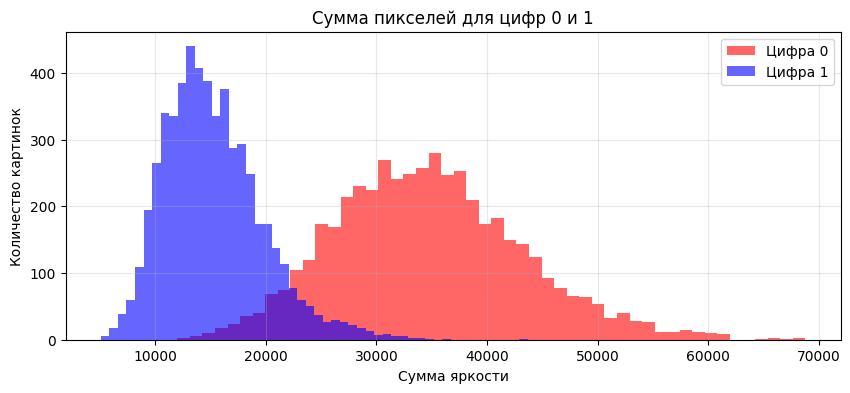

In [18]:
plt.figure(figsize=(10, 4))

# Строим две гистограммы: одну для нулей, другую для единиц
plt.hist(train_ink_mass[y_train == '0'], bins=50, alpha=0.6, label='Цифра 0', color='red')
plt.hist(train_ink_mass[y_train == '1'], bins=50, alpha=0.6, label='Цифра 1', color='blue')

plt.title('Cумма пикселей для цифр 0 и 1')
plt.xlabel('Сумма яркости')
plt.ylabel('Количество картинок')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Как мы видим эти 2 класса очень хорошо разделяются. Но что будет когда мы посчитаем распределение для всех 10 цифр?

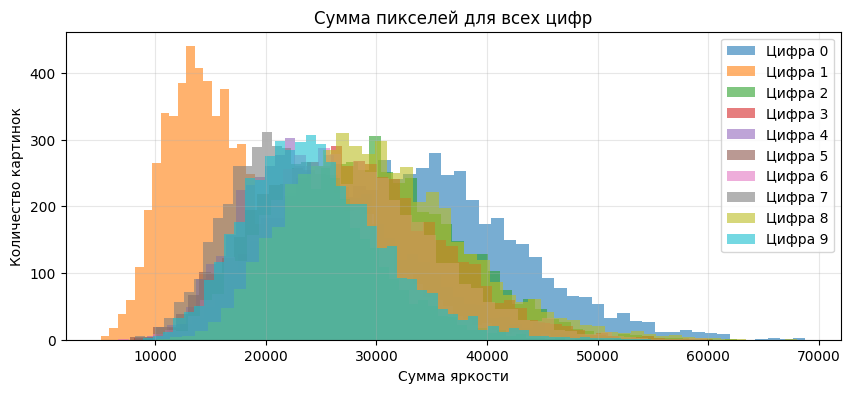

In [19]:
plt.figure(figsize=(10, 4))

for digit in np.unique(y_train):
    plt.hist(train_ink_mass[y_train == digit], bins=50, alpha=0.6, label=f'Цифра {digit}')

plt.title('Cумма пикселей для всех цифр')
plt.xlabel('Сумма яркости')
plt.ylabel('Количество картинок')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Для всех цифр, разделить каждую уже сложнее, но у нас хорошо различается цифра 1. Составим следующую модель:

* Определим 1 по отсечке по интесивности
* Остальные цифры выберем случайно

In [20]:
def first_model(
    X: Union[np.ndarray, List[List[float]]], 
    threshold: float
) -> np.ndarray:
    """
    Базовая модель классификации, комбинирующая интенсивность признаков и случайное предсказание.
    
    Модель выполняет две операции:
    1. Вычисляет интенсивность для каждого образца как сумму его признаков
    2. Сравнивает интенсивность с пороговым значением
    3. Для образцов с интенсивностью ниже порога предсказывает класс '1'
    4. Для остальных образцов генерирует случайные предсказания от 0 до 9

    Аргументы:
    ----------
    X : Union[np.ndarray, List[List[float]]]
        Матрица признаков размером (n_samples, n_features).
        Может быть:
        - numpy массивом float или int
        - списком списков чисел
    threshold : float
        Пороговое значение для интенсивности признаков.
        Образцы с суммой признаков < threshold классифицируются как класс '1'.
        Для остальных генерируются случайные метки классов от 0 до 9.
    
    Возвращает:
    -----------
    np.ndarray
        Массив предсказанных меток классов в строковом формате.
        Форма: (n_samples,)
        Тип данных: строки (dtype='<U1' или '<U2' для многозначных чисел)
    """

    intensity = X.sum(axis=1)

    n_samples = X.shape[0]
    y_pred = np.random.randint(0, 10, size=n_samples)

    y_pred = np.where(intensity < threshold, 1, y_pred)

    return y_pred.astype(str)

<div style="box-sizing:border-box;max-width:100%;margin:14px 0 0;padding:0;border:1px solid rgba(199,50,78,0.20);border-bottom:0;border-radius:12px 12px 0 0;overflow:hidden;color:inherit;"><span style="display:inline-block;padding:4px 11px;border-radius:4px 12px 12px 4px;background:linear-gradient(135deg,#D4470E,#C7324E,#B316B8);color:white;font-size:10.5px;font-weight:800;letter-spacing:0.06em;text-transform:uppercase;white-space:nowrap;">Вопрос</span></div>

<div style="box-sizing:border-box;max-width:100%;padding:10px 14px 13px;border-left:1px solid rgba(199,50,78,0.20);border-right:1px solid rgba(199,50,78,0.20);border-bottom:1px solid rgba(199,50,78,0.20);border-radius:0 0 12px 12px;margin-bottom:8px;">

<div style="box-sizing:border-box;max-width:100%;padding:10px 14px 13px;border-left:1px solid rgba(199,50,78,0.20);border-right:1px solid rgba(199,50,78,0.20);border-bottom:1px solid rgba(199,50,78,0.20);border-radius:0 0 12px 12px;margin-bottom:8px;">

Что в данном случае является обучением модели?

</div>

</div>

<details style="box-sizing:border-box;max-width:100%;margin:0 0 18px;padding:8px 14px 10px;border:1px solid rgba(199,50,78,0.20);border-radius:10px;color:inherit;">

<summary style="cursor:pointer;color:inherit;font-size:13px;font-weight:750;text-decoration:underline;text-decoration-color:#C7324E;text-decoration-thickness:1.5px;text-underline-offset:3px;">Показать ответ</summary>

> В данном случае обучением модели является определение значения отсечки по которой мы находим единицу. Мы это указали явно по визуальному анализу.

</details><br/>

In [21]:
y_pred_fast = first_model(X_test, threshold=14000)

score = accuracy_score(y_test, y_pred_fast)
print(f"метрика accuracy = {score*100:.2f}%")

метрика accuracy = 14.35%


Одно рассуждение уже подняло качество модели на 4% относительно бейзлайна!

Но это все еще довольно мало. Нам нужны еще признаки по которым мы можем классифицировать.


### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">5.2</span> <span style="color:inherit;">Попытка улучшения</span>

Вспомним что мы работаем с изображениями и попробуем разделить его на 4 части и смотреть суммарную интенсивность на каждой части отдельно. Для начала разделим изображения на 4 части, для этого придется обратно перевести вектор в матрицу

In [22]:
def extract_quadrant_features(X: np.ndarray) -> np.ndarray:
    """
    Извлекает четыре квадрантных признака из изображений 28x28.
    
    Каждое изображение делится на 4 равных квадранта (14x14) и вычисляется
    сумма интенсивности пикселей в каждом квадранте.
    
    Аргументы:
    ----------
    X : np.ndarray
        Входные данные в виде плоского массива изображений.
        Форма: (n_samples, 784), где 784 = 28*28 пикселей.
        Предполагается, что пиксели нормализованы в диапазоне [0, 1] или [0, 255].
    
    Возвращает:
    -----------
    np.ndarray
        Матрицу квадрантных признаков.
        Форма: (n_samples, 4), где 4 признака соответствуют:
        0: top_left, 1: top_right, 2: bottom_left, 3: bottom_right
    """
    # 1. Возвращаем форму картинок (N образцов, 28 высота, 28 ширина)
    images = X.reshape(-1, 28, 28)

    # 2. Нарезаем на 4 части
    top_left = images[:, :14, :14]
    top_right = images[:, :14, 14:]
    bottom_left = images[:, 14:, :14]
    bottom_right = images[:, 14:, 14:]

    # 3. Считаем сумму пикселей в каждом блоке
    # axis=(1, 2) означает сумму по высоте и ширине блока
    f1 = top_left.sum(axis=(1, 2))
    f2 = top_right.sum(axis=(1, 2))
    f3 = bottom_left.sum(axis=(1, 2))
    f4 = bottom_right.sum(axis=(1, 2))

    # 4. Собираем 4 признака в одну матрицу (N, 4)
    return np.column_stack((f1, f2, f3, f4))

Преобразуем признаки.

In [23]:
X_train_quadrants = extract_quadrant_features(X_train)
X_train_quadrants.shape

(49000, 4)

Посмотрим на распределение интенсивности в секторах для разных классов.

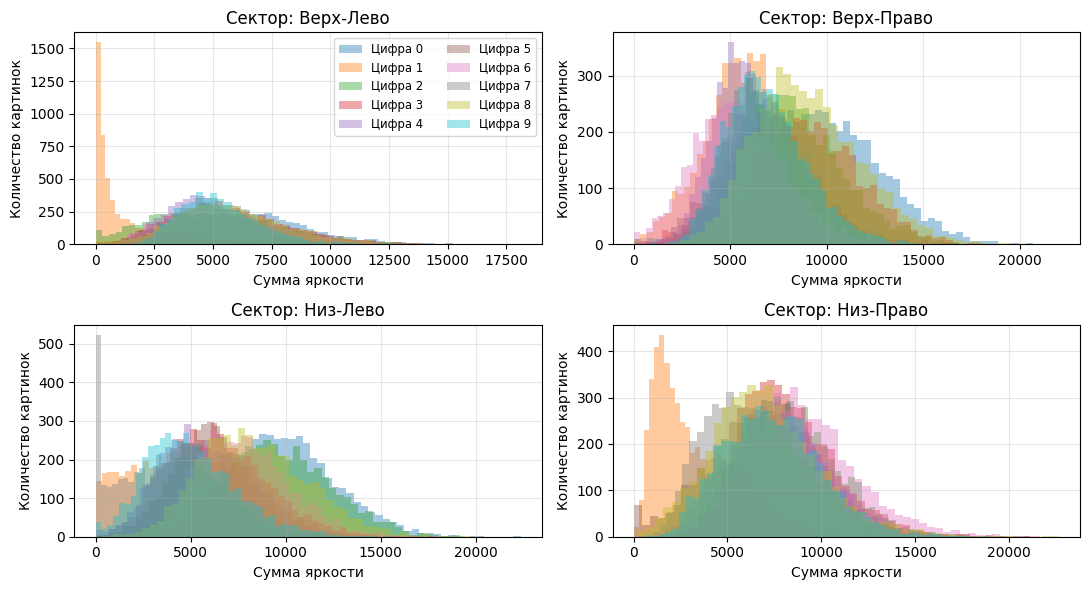

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
axes = axes.flatten()

quadrants_names = ['Верх-Лево', 'Верх-Право', 'Низ-Лево', 'Низ-Право']

for i, ax in enumerate(axes):
    name = quadrants_names[i]

    for digit in np.unique(y_train):
        ax.hist(X_train_quadrants[y_train == digit,i], bins=50, alpha=0.4, label=f'Цифра {digit}')

        ax.set_title(f'Сектор: {name}')
        ax.set_xlabel('Сумма яркости')
        ax.set_ylabel('Количество картинок')
        ax.grid(True, alpha=0.3)
        
        if i == 0: # Рисуем легенду только на первом, чтобы не захламлять
            ax.legend(loc='upper right', fontsize='small', ncol=2)

plt.tight_layout()
plt.show()

Классы также разделяются довольно плохо, но мы можем выделить 1 и 7. Составим следующую модель:

* Интенсивность сектора "Верх-лево" < 1000 &mdash; классифицируем как 1
* Интенсивность сектора "Верх-лево" > 1000 и Интенсивность сектора "Низ-лево" < 1000 &mdash; классифицируем как 7
* Все остальное предсказываем случайно

In [25]:
def quadrant_model_vectorized(
    X: np.ndarray, 
    threshold_1: float = 1500, 
    threshold_2: float = 1500
) -> np.ndarray:
    """
    Векторизованная модель классификации на основе квадрантных признаков.
    
    Модель использует эвристические правила для классификации цифр MNIST:
    - Если в верхнем левом квадранте мало интенсивности (< threshold_1), предсказывает '1'
    - Если в верхнем левом много интенсивности (> threshold_1) 
      И в нижнем левом мало интенсивности (< threshold_2), предсказывает '7'
    - Для остальных случаев генерирует случайные предсказания от 0 до 9
    
    Аргументы:
    ----------
    X : np.ndarray
        Входные данные в виде плоского массива изображений.
        Форма: (n_samples, 784), где 784 = 28*28 пикселей.
        Предполагается, что пиксели в диапазоне [0, 255] для MNIST.
    threshold_1 : float, default=1500
        Порог интенсивности для верхнего левого квадранта.
        Используется для разделения цифр '1' и других.
        Значение основано на эмпирических наблюдениях для MNIST.
    threshold_2 : float, default=1500
        Порог интенсивности для нижнего левого квадранта.
        Используется в комбинации с threshold_1 для выделения цифры '7'.
    
    Возвращает:
    -----------
    np.ndarray
        Массив предсказанных меток в строковом формате.
        Форма: (n_samples,)
        Возможные значения: строковые представления цифр от '0' до '9'.
    """
    n_samples = X.shape[0]

    # Получаем матрицу (N, 4)
    features = extract_quadrant_features(X)

    # 2. Вытаскиваем нужные признаки по индексам
    # Индекс 0 = Top-Left
    q_top_left = features[:, 0]

    # Индекс 2 = Bottom-Left
    q_bot_left = features[:, 2]

    # Условие 1: Это Единица? (Мало чернил слева сверху)
    cond_1 = (q_top_left < threshold_1)

    # Условие 2: Это Семерка?
    # (Много чернил слева сверху И Мало слева снизу)
    cond_7 = (q_top_left > threshold_1) & (q_bot_left < threshold_2)

    # 4. Сборка ответа
    conditions = [cond_1, cond_7]
    choices = ['1', '7']

    # Рандом для остальных
    random_defaults = np.random.randint(0, 10, size=n_samples).astype(str)

    y_pred = np.select(conditions, choices, default=random_defaults)

    return y_pred

Протестируем модель.

In [26]:
y_pred_quad = quadrant_model_vectorized(X_test, threshold_1=2000, threshold_2=2000)

score = accuracy_score(y_test, y_pred_quad)
print(f"метрика accuracy = {score*100:.2f}%")

метрика accuracy = 19.61%


Подняли итоговое качество еще на 5%!


### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">5.3</span> <span style="color:inherit;">Работаем дальше</span>

Добавим следующий признак &mdash; посмотрим на интенсивность в центре. Это должно позволить нам отличить цифры вроде 0 где в центре ничего нет от 8 где центр закрашен, хотя суммарная интенсивность у них схожая.

In [27]:
def extract_center_feature(
    X: np.ndarray, 
    margin: int = 4
) -> np.ndarray:
    """
    Вычисляет сумму яркости в центральном квадрате изображений MNIST.
    
    Функция извлекает центральную область изображения и вычисляет
    общую интенсивность пикселей в этой области. Центральная область
    часто содержит важную информацию для распознавания цифр.
    
    Аргументы:
    ----------
    X : np.ndarray
        Входные данные в виде плоского массива изображений.
        Форма: (n_samples, 784), где 784 = 28*28 пикселей.
        Предполагается, что пиксели нормализованы в диапазоне [0, 1] или [0, 255].
    margin : int, default=4
        Отступ от центра изображения. Центральный квадрат имеет координаты:
    
    Возвращает:
    -----------
    np.ndarray
        Вектор интенсивностей центральных областей.
        Форма: (n_samples, 1)
    """
    # 1. Возвращаем форму картинок (N, 28, 28)
    images = X.reshape(-1, 28, 28)

    # 2. Вычисляем координаты среза
    center = 14
    start = center - margin
    end = center + margin

    # 3. Вырезаем центр и считаем сумму
    center_patch = images[:, start:end, start:end]
    center_mass = center_patch.sum(axis=(1, 2))

    return center_mass.reshape(-1, 1)

Преобразуем признаки.

In [28]:
X_train_center = extract_center_feature(X_train)
X_train_center.shape

(49000, 1)

Посмотрим на распределение интенсивности в центре.

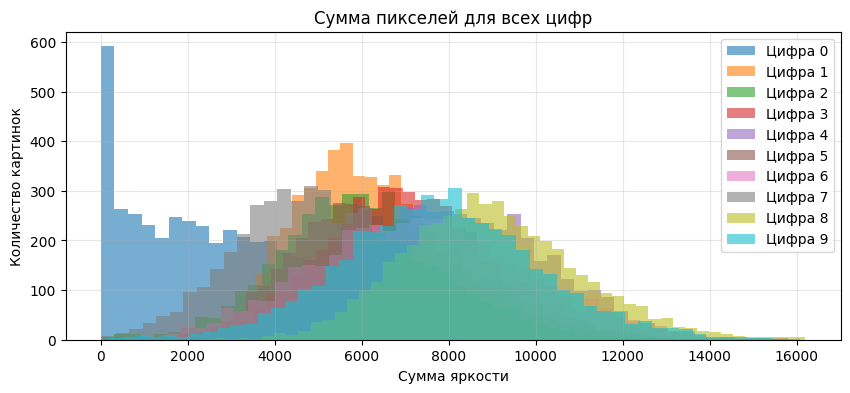

In [29]:
plt.figure(figsize=(10, 4))

for digit in np.unique(y_train):
    plt.hist(X_train_center[y_train == digit], bins=50, alpha=0.6, label=f'Цифра {digit}')

plt.title('Cумма пикселей для всех цифр')
plt.xlabel('Сумма яркости')
plt.ylabel('Количество картинок')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

На графике хорошо разделяется только 0. Составим следующую модель:

* Если интенсивность в центре < 2000 &mdash; классифицируем объект как 0
* Иначе выбираем случайно

In [30]:
def center_hole_model(X: np.ndarray, threshold: float = 2000) -> np.ndarray:
    """
    Классификатор, определяющий цифру '0' по низкой интенсивности в центре изображения.
    
    Модель основана на эвристике: цифра '0' обычно имеет низкую интенсивность пикселей
    в центральной области из-за отверстия в центре. Все остальные цифры классифицируются
    случайным образом.
    
    Аргументы:
    ----------
    X : np.ndarray
        Входные данные в виде плоского массива изображений.
        Форма: (n_samples, 784), где 784 = 28*28 пикселей.
        Предполагается, что пиксели в диапазоне [0, 255] для MNIST.
    threshold : float, default=2000
        Порог интенсивности для центральной области.
        Если сумма яркости в центральной области (8x8 пикселей) меньше порога,
        изображение классифицируется как '0'.
    
    Возвращает:
    -----------
    np.ndarray
        Массив предсказанных меток в строковом формате.
        Форма: (n_samples,)
        Значения: строковые представления цифр от '0' до '9'.
    """
    # 1. Считаем признак
    center_intensity = extract_center_feature(X, margin=4).flatten()

    n_samples = X.shape[0]

    # 2. База: Генерируем случайные предсказания для ВСЕХ
    y_pred = np.random.randint(0, 10, size=n_samples).astype(str)

    # 3. Условие (Маска)
    is_zero_likely = center_intensity < threshold

    # 4. Применяем правило: заменяем рандом на '0' там, где условие выполнено
    y_pred[is_zero_likely] = '0'

    return y_pred

Протестируем модель

In [31]:
y_pred_quad = center_hole_model(X_test, threshold=3000)

score = accuracy_score(y_test, y_pred_quad)
print(f"метрика accuracy = {score*100:.2f}%")

метрика accuracy = 14.44%


Качество хуже предыдущей модели, печалька...


### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">5.4</span> <span style="color:inherit;">Ну, пожалуйста, еще разочек!</span>

Заметим, что мы использовали разные признаки для определения разных цифр мы можем совместить эти две идеи в одну.

In [32]:
def combined_rules_model(
    X: np.ndarray, 
    threshold_tl: float = 2000, 
    threshold_bl: float = 2000, 
    threshold_center: float = 3000
) -> np.ndarray:
    """
    Комбинированный классификатор, объединяющий правила для цифр 0, 1 и 7.
    
    Модель последовательно применяет три эвристических правила:
    1. Если мало интенсивности в верхнем левом квадранте → предсказывает '1'
    2. Если низкая интенсивность в центральной области → предсказывает '0'
    3. Если много интенсивности в верхнем левом И мало в нижнем левом квадранте → предсказывает '7'
    4. Если ни одно правило не сработало → случайное предсказание
    
    Аргументы:
    ----------
    X : np.ndarray
        Входные данные в виде плоского массива изображений.
        Форма: (n_samples, 784), где 784 = 28*28 пикселей.
        Предполагается, что пиксели в диапазоне [0, 255] для MNIST.
    threshold_tl : float, default=2000
        Порог интенсивности для верхнего левого квадранта (14x14 пикселей).
        Используется в правилах для цифр '1' и '7'.
    threshold_bl : float, default=2000
        Порог интенсивности для нижнего левого квадранта (14x14 пикселей).
        Используется в правиле для цифры '7'.
    threshold_center : float, default=3000
        Порог интенсивности для центральной области (8x8 пикселей при margin=4).
        Используется в правиле для цифры '0'.
    
    Возвращает:
    -----------
    np.ndarray
        Массив предсказанных меток в строковом формате.
        Форма: (n_samples,)
        Значения: строковые представления цифр от '0' до '9'.
    
    Порядок применения правил:
    -------------------------
    Правила применяются последовательно в порядке: 1 → 0 → 7
    Если срабатывает правило для '1', проверка остальных правил не выполняется.
    """
    n_samples = X.shape[0]


    # А. Получаем квадранты (вызываем твою первую функцию)
    quad_features = extract_quadrant_features(X)

    q_top_left = quad_features[:, 0] # Индекс 0
    q_bot_left = quad_features[:, 2] # Индекс 2

    # Условие 1: Единица (Мало чернил слева сверху)
    cond_1 = (q_top_left < threshold_tl)

    # Условие 2: Семерка (Много слева сверху И Мало слева снизу)
    cond_7 = (q_top_left > threshold_tl) & (q_bot_left < threshold_bl)

    # Условие 3: Ноль (Пустой центр)
    center_mass = extract_center_feature(X, margin=4).flatten()
    cond_0 = (center_mass < threshold_center)

    # Порядок проверки: Сначала 1, если нет - проверяем на 0, если нет - на 7.
    conditions = [cond_1, cond_0, cond_7]
    choices = ['1', '0', '7']

    # Если ничего не подошло - рандом
    random_defaults = np.random.randint(0, 10, size=n_samples).astype(str)

    y_pred = np.select(conditions, choices, default=random_defaults)

    return y_pred

In [33]:
y_pred_quad = combined_rules_model(X_test, threshold_tl=2000, threshold_bl=2000, threshold_center=3000)

score = accuracy_score(y_test, y_pred_quad)
print(f"метрика accuracy = {score*100:.2f}%")

метрика accuracy = 23.60%


**Итог.** Мы потратили кучу времени, придумывая логические правила и добились качества лишь в 23.6% 😂

Дело в том, что исходная размерность изображения 784, мы же сравнивали их только по трем признакам. Мы научились отлично находить нули и единицы. Но чтобы придумать правила для 5, 3, 8, 9... нам придется написать сотни условий.

Вместо того чтобы мучиться, давайте возьмем модель, который сам найдет эти закономерности, сравнивая картинки целиком.

## <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">6</span> <span style="color:inherit;">Метод ближайших соседей</span>

Обучим нашу первую серьезную модель &mdash; kNN-классификатор. Готовая [реализация](https://scikit-learn.org/1.5/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) этой модели уже есть в модуле `sklearn.neighbors`.

Создадим экземпляр классификатора:

- `n_neighbors`: количество соседей для учитывания при классификации.
- `weights`: веса, присваиваемые соседям (`uniform` &mdash; все веса одинаковы, `distance` &mdash; вес зависит от расстояния).
- `algorithm`: алгоритм для поиска ближайших соседей (`auto`, `ball_tree`, `kd_tree` `brute`).
- `p`: параметр метрики расстояния (1 &mdash; манхэттенское расстояние, 2 &mdash; евклидово расстояние и т.д.).

Выберем число соседей `n_neighbors = 5`, остальные параметры оставим по умолчанию.

<div style="box-sizing:border-box;max-width:100%;margin:14px 0 0;padding:0;border:1px solid rgba(199,50,78,0.20);border-bottom:0;border-radius:12px 12px 0 0;overflow:hidden;color:inherit;"><span style="display:inline-block;padding:4px 11px;border-radius:4px 12px 12px 4px;background:linear-gradient(135deg,#D4470E,#C7324E,#B316B8);color:white;font-size:10.5px;font-weight:800;letter-spacing:0.06em;text-transform:uppercase;white-space:nowrap;">Вопрос</span></div>

<div style="box-sizing:border-box;max-width:100%;padding:10px 14px 13px;border-left:1px solid rgba(199,50,78,0.20);border-right:1px solid rgba(199,50,78,0.20);border-bottom:1px solid rgba(199,50,78,0.20);border-radius:0 0 12px 12px;margin-bottom:8px;">

<div style="box-sizing:border-box;max-width:100%;padding:10px 14px 13px;border-left:1px solid rgba(199,50,78,0.20);border-right:1px solid rgba(199,50,78,0.20);border-bottom:1px solid rgba(199,50,78,0.20);border-radius:0 0 12px 12px;margin-bottom:8px;">

Как изменится точность модели, если использовать слишком большое значение $k$ (параметр `n_neighbors`)?

</div>

</div>

<details style="box-sizing:border-box;max-width:100%;margin:0 0 18px;padding:8px 14px 10px;border:1px solid rgba(199,50,78,0.20);border-radius:10px;color:inherit;">

<summary style="cursor:pointer;color:inherit;font-size:13px;font-weight:750;text-decoration:underline;text-decoration-color:#C7324E;text-decoration-thickness:1.5px;text-underline-offset:3px;">Показать ответ</summary>

> Когда параметр $k$ увеличивается, модель начинает учитывать больше ближайших соседей для принятия решения о классе объекта. При большом значении $k$ модель становится менее чувствительной к выбросам, так как решение принимается не только по ближайшим точкам, но и по большему числу соседей. Однако увеличение $k$ также может привести к потере важной локальной информации. Если данные имеют сложную структуру с множеством мелких кластеров, то использование большого числа соседей может сгладить эти особенности и ухудшить точность классификации в таких областях.

</details><br/>

### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">6.1</span> <span style="color:inherit;">Построение модели</span>

In [34]:
model = KNeighborsClassifier(n_neighbors=5, algorithm="brute")

Для обучения *любой* модели в sklearn-е используется метод класса  `fit(X_train, y_train)`.

- `X_train`: массив признаков обучающей выборки.
- `y_train`: массив меток классов обучающей выборки.

In [35]:
model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


<div style="box-sizing:border-box;max-width:100%;margin:14px 0 0;padding:0;border:1px solid rgba(199,50,78,0.20);border-bottom:0;border-radius:12px 12px 0 0;overflow:hidden;color:inherit;"><span style="display:inline-block;padding:4px 11px;border-radius:4px 12px 12px 4px;background:linear-gradient(135deg,#D4470E,#C7324E,#B316B8);color:white;font-size:10.5px;font-weight:800;letter-spacing:0.06em;text-transform:uppercase;white-space:nowrap;">Вопрос</span></div>

<div style="box-sizing:border-box;max-width:100%;padding:10px 14px 13px;border-left:1px solid rgba(199,50,78,0.20);border-right:1px solid rgba(199,50,78,0.20);border-bottom:1px solid rgba(199,50,78,0.20);border-radius:0 0 12px 12px;margin-bottom:8px;">

<div style="box-sizing:border-box;max-width:100%;padding:10px 14px 13px;border-left:1px solid rgba(199,50,78,0.20);border-right:1px solid rgba(199,50,78,0.20);border-bottom:1px solid rgba(199,50,78,0.20);border-radius:0 0 12px 12px;margin-bottom:8px;">

Что метод `fit` сделал в данном случае? Что есть обучение kNN?

</div>

</div>

<details style="box-sizing:border-box;max-width:100%;margin:0 0 18px;padding:8px 14px 10px;border:1px solid rgba(199,50,78,0.20);border-radius:10px;color:inherit;">

<summary style="cursor:pointer;color:inherit;font-size:13px;font-weight:750;text-decoration:underline;text-decoration-color:#C7324E;text-decoration-thickness:1.5px;text-underline-offset:3px;">Показать ответ</summary>

> В контексте kNN в случае `algorithm="brute"` "обучением" называется процесс запоминания всех данных, предоставленных для обучения. То есть модель просто сохраняет все точки данных вместе с их метками классов. Никакие дополнительные вычисления или оптимизации параметров не производятся.
>
> С одной стороны это делает kNN простым и адаптивным, так как, если данные обновляются, новая версия модели создается мгновенно. Однако, с другой стороны, это замедляет работу модели и снижает ее эффективность на сложных задачах, где требуется выявление сложных взаимосвязей в данных.

</details><br/>


Теперь когда мы обучили модель, мы можем использовать ее для получения предсказаний. Для этого аналогично обучению существует метод `model.predict(X_test) `

- `X_test`: массив признаков тестовой выборки.

In [36]:
y_pred = model.predict(X_test)

<div style="box-sizing:border-box;max-width:100%;margin:14px 0 0;padding:0;border:1px solid rgba(199,50,78,0.20);border-bottom:0;border-radius:12px 12px 0 0;overflow:hidden;color:inherit;"><span style="display:inline-block;padding:4px 11px;border-radius:4px 12px 12px 4px;background:linear-gradient(135deg,#D4470E,#C7324E,#B316B8);color:white;font-size:10.5px;font-weight:800;letter-spacing:0.06em;text-transform:uppercase;white-space:nowrap;">Вопрос</span></div>

<div style="box-sizing:border-box;max-width:100%;padding:10px 14px 13px;border-left:1px solid rgba(199,50,78,0.20);border-right:1px solid rgba(199,50,78,0.20);border-bottom:1px solid rgba(199,50,78,0.20);border-radius:0 0 12px 12px;margin-bottom:8px;">

<div style="box-sizing:border-box;max-width:100%;padding:10px 14px 13px;border-left:1px solid rgba(199,50,78,0.20);border-right:1px solid rgba(199,50,78,0.20);border-bottom:1px solid rgba(199,50,78,0.20);border-radius:0 0 12px 12px;margin-bottom:8px;">

Что метод `predict` сделал в данном случае? Что есть предсказание kNN?

</div>

</div>

<details style="box-sizing:border-box;max-width:100%;margin:0 0 18px;padding:8px 14px 10px;border:1px solid rgba(199,50,78,0.20);border-radius:10px;color:inherit;">

<summary style="cursor:pointer;color:inherit;font-size:13px;font-weight:750;text-decoration:underline;text-decoration-color:#C7324E;text-decoration-thickness:1.5px;text-underline-offset:3px;">Показать ответ</summary>

> Для каждого объекта из тестовой выборки:
> 1. Вычисление расстояния от этого объекта до каждого объекта обучающей выборки, которую модель просто «запомнила» на этапе `fit`. По умолчанию это евклидово расстояние
> $$\rho(a, b) = \sqrt{ \sum\limits_{j=1}^d \left( a_j - b_j \right)^2 }.$$
>
>
> 2. Cортировка полученного списка расстояний от меньшего к большему.
> Модели нужно найти те объекты из базы, расстояние до которых минимально (они самые похожие).
>
> 3. Из отсортированного списка модель берет только первые $k$ элементов, смотрит на их таргетные метки, и выдает самую частую.

</details><br/>

При работе с большими наборами данных поиск ближайших соседей может занять значительное время. Для ускорения можно использовать специализированные структуры данных:
- KD-дерево (`algorithm="kd_tree"`): позволяет быстро находить ближайшие соседи за логарифмическое время,
- BallTree (`algorithm="ball_tree"`): еще одна структура данных, которая ускоряет поиск.  




<div style="box-sizing:border-box;max-width:100%;margin:14px 0 0;padding:0;border:1px solid rgba(199,50,78,0.20);border-bottom:0;border-radius:12px 12px 0 0;overflow:hidden;color:inherit;"><span style="display:inline-block;padding:4px 11px;border-radius:4px 12px 12px 4px;background:linear-gradient(135deg,#D4470E,#C7324E,#B316B8);color:white;font-size:10.5px;font-weight:800;letter-spacing:0.06em;text-transform:uppercase;white-space:nowrap;">Вопрос</span></div>

<div style="box-sizing:border-box;max-width:100%;padding:10px 14px 13px;border-left:1px solid rgba(199,50,78,0.20);border-right:1px solid rgba(199,50,78,0.20);border-bottom:1px solid rgba(199,50,78,0.20);border-radius:0 0 12px 12px;margin-bottom:8px;">

<div style="box-sizing:border-box;max-width:100%;padding:10px 14px 13px;border-left:1px solid rgba(199,50,78,0.20);border-right:1px solid rgba(199,50,78,0.20);border-bottom:1px solid rgba(199,50,78,0.20);border-radius:0 0 12px 12px;margin-bottom:8px;">

Почему метод kNN может работать медленно на больших данных?

</div>

</div>

<details style="box-sizing:border-box;max-width:100%;margin:0 0 18px;padding:8px 14px 10px;border:1px solid rgba(199,50,78,0.20);border-radius:10px;color:inherit;">

<summary style="cursor:pointer;color:inherit;font-size:13px;font-weight:750;text-decoration:underline;text-decoration-color:#C7324E;text-decoration-thickness:1.5px;text-underline-offset:3px;">Показать ответ</summary>

> Основная операция метода kNN заключается в вычислении расстояния между каждым новым объектом и всеми объектами обучающей выборки. Для каждой новой точки нужно найти её $k$ ближайших соседей среди всех объектов в наборе данных. Если количество объектов велико, это требует значительных вычислительных ресурсов. Вычислительная сложность поиска ближайшего соседа для одного нового объекта составляет
$O(n\cdot d)$, где $n$ – число объектов в обучающем множестве, а $d$ – размерность пространства признаков.  
> 
> Простой подход к поиску ближайших соседей (brute force search) имеет высокую временную сложность $O(n)$.

</details><br/>

Посмотрим на результат предсказания.

In [37]:
y_pred.shape, y_pred[:15]

((21000,),
 array(['8', '4', '8', '7', '7', '0', '6', '2', '7', '4', '3', '9', '9',
        '8', '2'], dtype=object))

У нас есть истинные метки классов `y_test` и предсказанные моделью `y_pred`. Для оценки качества модели осталось только их сравнить.




<div style="box-sizing:border-box;max-width:100%;margin:14px 0 0;padding:0;border:1px solid rgba(199,50,78,0.20);border-bottom:0;border-radius:12px 12px 0 0;overflow:hidden;color:inherit;"><span style="display:inline-block;padding:4px 11px;border-radius:4px 12px 12px 4px;background:linear-gradient(135deg,#D4470E,#C7324E,#B316B8);color:white;font-size:10.5px;font-weight:800;letter-spacing:0.06em;text-transform:uppercase;white-space:nowrap;">Вопрос</span></div>

<div style="box-sizing:border-box;max-width:100%;padding:10px 14px 13px;border-left:1px solid rgba(199,50,78,0.20);border-right:1px solid rgba(199,50,78,0.20);border-bottom:1px solid rgba(199,50,78,0.20);border-radius:0 0 12px 12px;margin-bottom:8px;">

<div style="box-sizing:border-box;max-width:100%;padding:10px 14px 13px;border-left:1px solid rgba(199,50,78,0.20);border-right:1px solid rgba(199,50,78,0.20);border-bottom:1px solid rgba(199,50,78,0.20);border-radius:0 0 12px 12px;margin-bottom:8px;">

Если данные распределены неравномерно, например, одна часть плотно сгруппирована, а другая разрежена (см. ниже), как это может повлиять на результаты kNN? (картика не относится к датасету)

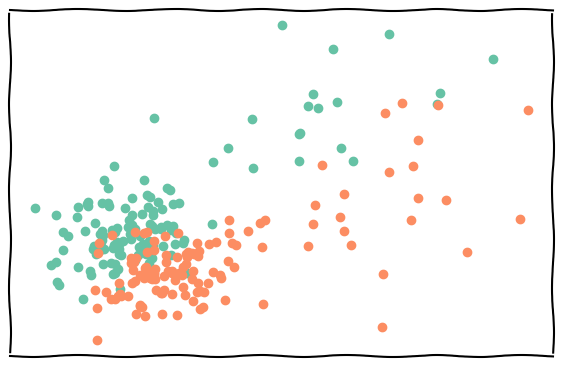

</div>

</div>

<details style="box-sizing:border-box;max-width:100%;margin:0 0 18px;padding:8px 14px 10px;border:1px solid rgba(199,50,78,0.20);border-radius:10px;color:inherit;">

<summary style="cursor:pointer;color:inherit;font-size:13px;font-weight:750;text-decoration:underline;text-decoration-color:#C7324E;text-decoration-thickness:1.5px;text-underline-offset:3px;">Показать ответ</summary>

>  Как мы помним, наш метод строит предсказания, основываясь на предположении о схожести соседних объектов в метрическом пространстве.

> В плотных областях данных в небольшой окрестности каждой точки расположено довольно много объектов, соответственно, принцип схожести будет соблюдаться в том числе и для больших $k$. Это позволит модели быть более устойчивой в этой области данных, менее зависимой от шумов в данных.

> Однако, в разреженных областях даже в большой окрестности будет расположено мало объектов, соответственно, для соблюдения принципа схожести необходимо брать небольшие значения $k$, иначе модель может выдавать сильно смещенные предсказания.

> В итоге получаем, что не существует значения $k$, которое было бы оптимальным для всего пространства данных.

</details><br/>

### <span style="display:inline-block;padding:2px 8px;border-radius:999px;background:linear-gradient(135deg, #C7480B 0%, #B52D59 54%, #A617B3 100%);color:#FFFFFF;font-size:0.78em;vertical-align:0.08em;">6.2</span> <span style="color:inherit;">Анализ результатов</span>

Давайте посмотрим на то, как предсказанные значения согласуются с реальными.

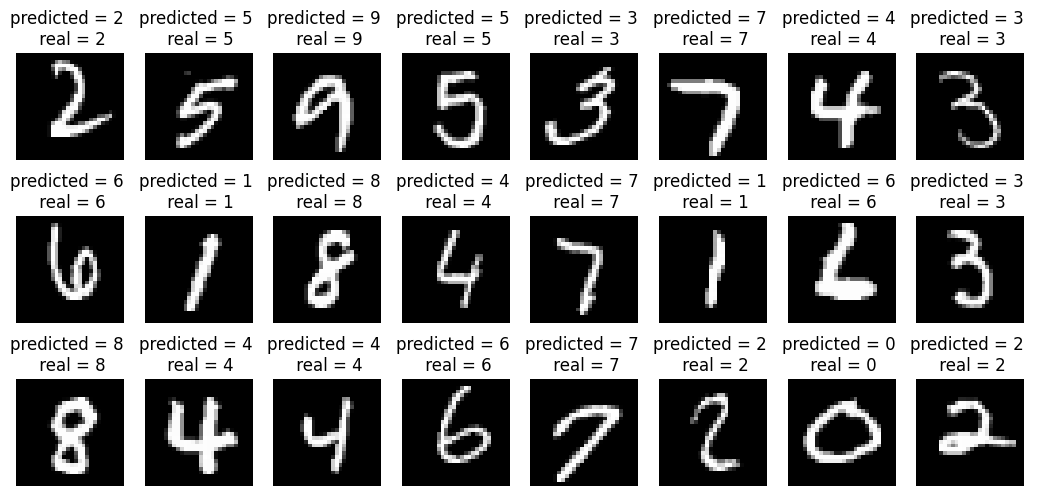

In [38]:
plt.figure(figsize=(13, 6))

for i in range(24):
    plt.subplot(3, 8, i + 1)
    image, predicted_label, real_label = get_random_image(X_test, y_pred, y_test)
    # выводим само изображение
    plt.imshow(image, cmap="gray")
    # выводим истинные и предсказанные метки
    plt.title(f"predicted = {predicted_label} \n real = {real_label}")
    plt.axis("off")
plt.show()

In [39]:
score = accuracy_score(y_test, y_pred)
print(f"метрика accuracy = {score*100:.2f}%")

метрика accuracy = 96.84%




Теперь мы можем утверждать, что модель k-ближайших соседей (kNN) продемонстрировала высокую точность в 96%, значительно превосходя базовый уровень в 11% и уровевь нашей собственной модели в 23%. Это подтверждает высокую эффективность модели в данном контексте. Однако стоит рассмотреть, как другие современные модели справляются с аналогичными задачами.


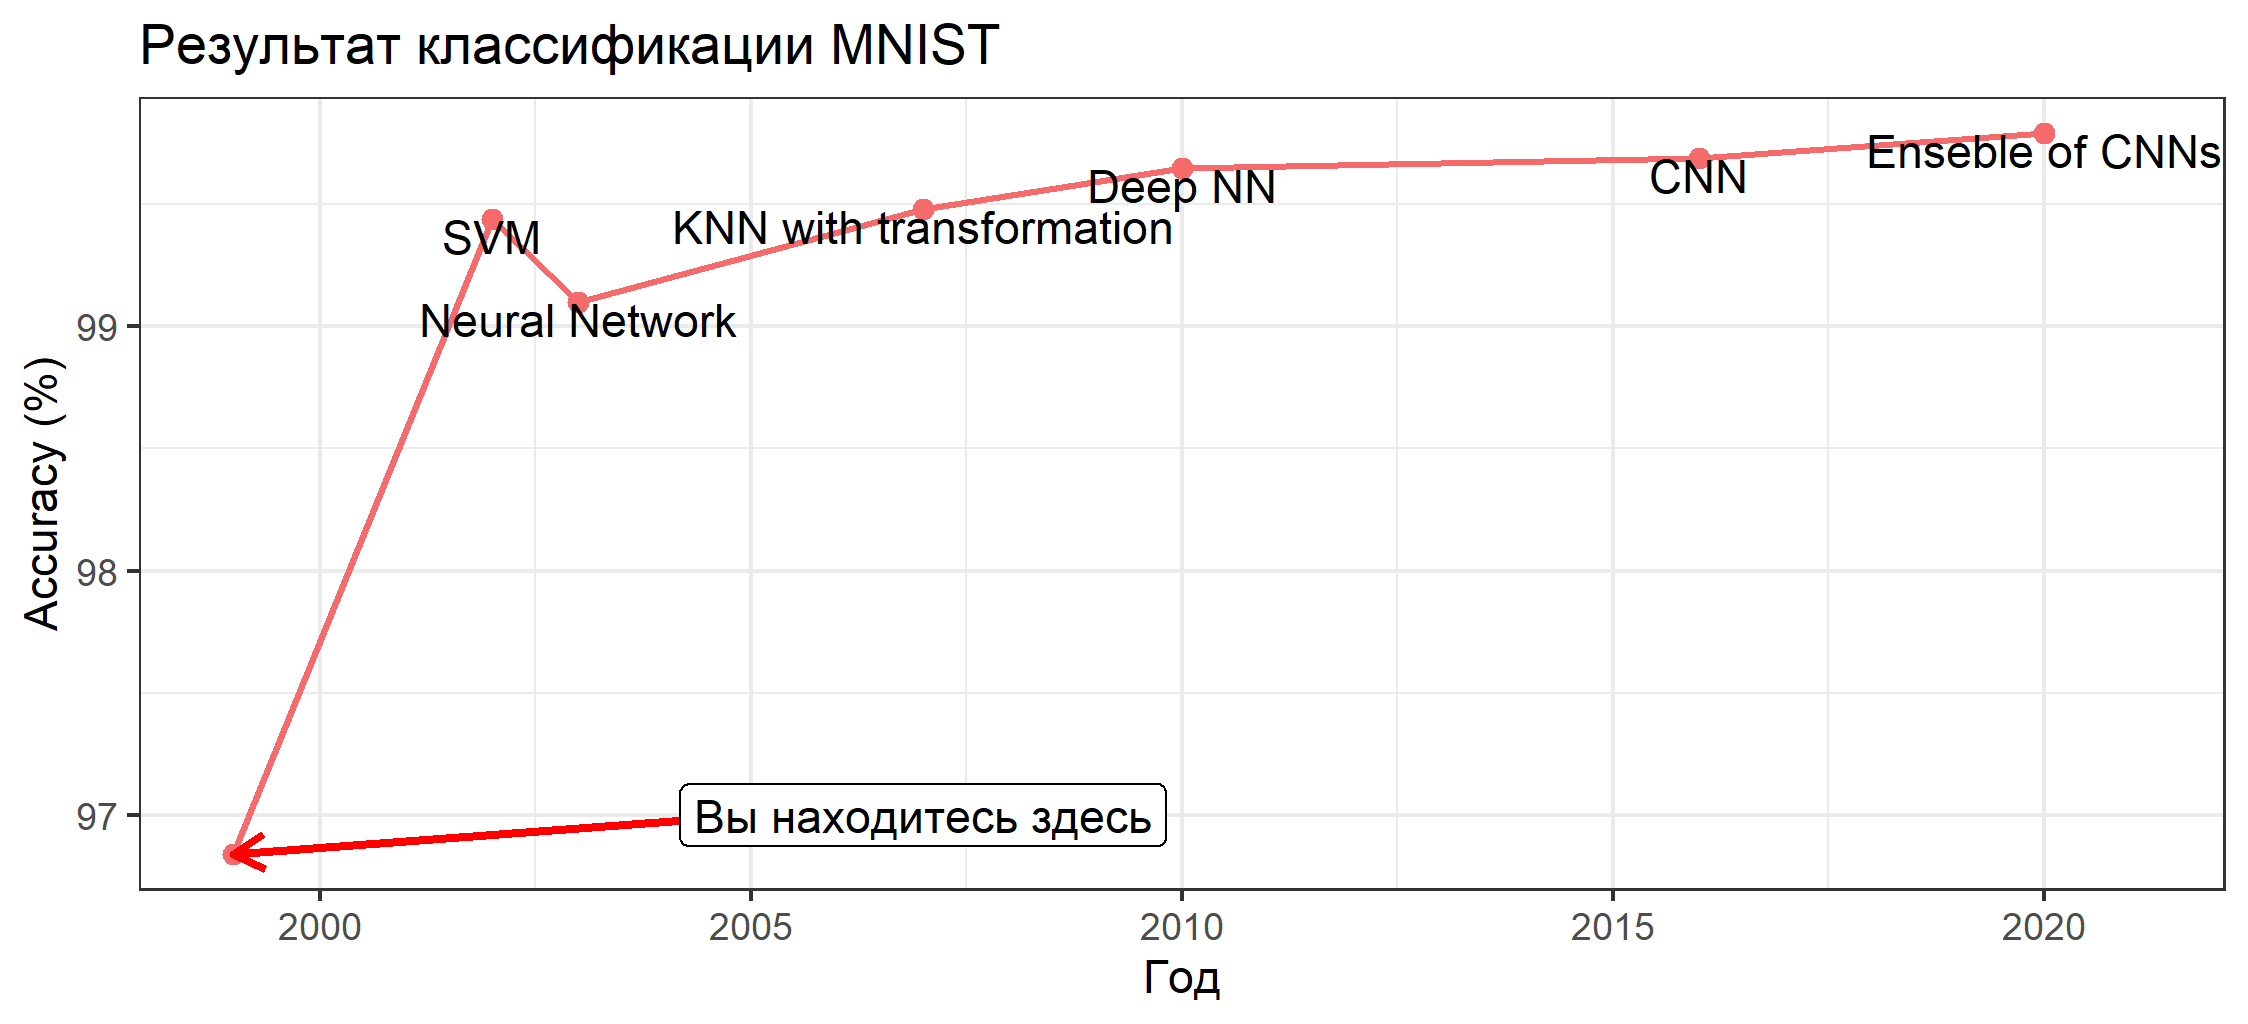

Подробнее об этом можно почитать [здесь](https://web.archive.org/web/20220509025752/http://yann.lecun.com/exdb/mnist/).

История классификации датасета MNIST отражает эволюцию методов машинного обучения и искусственного интеллекта. От простых линейных классификаторов до глубоких сверточных нейронных сетей — прогресс был значительным. Сегодня MNIST служит скорее отправной точкой для изучения новых идей и технологий, нежели сложной задачей, требующей решения. Тем не менее, современные модели, такие как сверточные нейронные сети (CNN), рекуррентные нейронные сети (RNN) и трансформеры, продолжают совершенствоваться, предлагая все более точные и эффективные решения для разнообразных задач, выходящих далеко за рамки простого распознавания рукописных цифр. И наша цель познакомить вас со всем многообразием этих моделей от самых простых до самых эффективных.



<div style="box-sizing:border-box;max-width:100%;margin-top:42px;padding:18px 0 4px;border-top:1px solid rgba(127, 127, 127, 0.28);color:inherit;font-size:0.9em;line-height:1.5;"><img src="https://thetahat.ru/images/logo_thetahat.png" alt="ThetaHat" style="display:block!important;width:34px!important;max-width:34px!important;height:auto!important;margin:0 0 9px 0!important;padding:0!important;">© 2026 команда <a href="https://thetahat.ru/" style="color:inherit;font-weight:750;text-decoration:underline;text-decoration-color:#F13A3F;text-underline-offset:3px;">ThetaHat</a> для курса ML-1 ШАД</div>